# tfTTs to mp3 and play it on Streamlit web app

2023-03-20

[ TTS ]

    TensorFlowTTS : Transformer TTS based on Tensorflow
    https://github.com/TensorSpeech/TensorFlowTTS
    https://huggingface.co/spaces/akhaliq/TensorFlowTTS

    Chinese Mandarin text into professional speech
    https://ttsmp3.com/text-to-speech/Chinese%20Mandarin/


## How to play an audio file automatically (generated using text-to-speech) in Streamlit?

https://discuss.streamlit.io/t/how-to-play-an-audio-file-automatically-generated-using-text-to-speech-in-streamlit/33201

自動播放沒有作用，請打開網頁瀏覽器的允許播放音效設定。
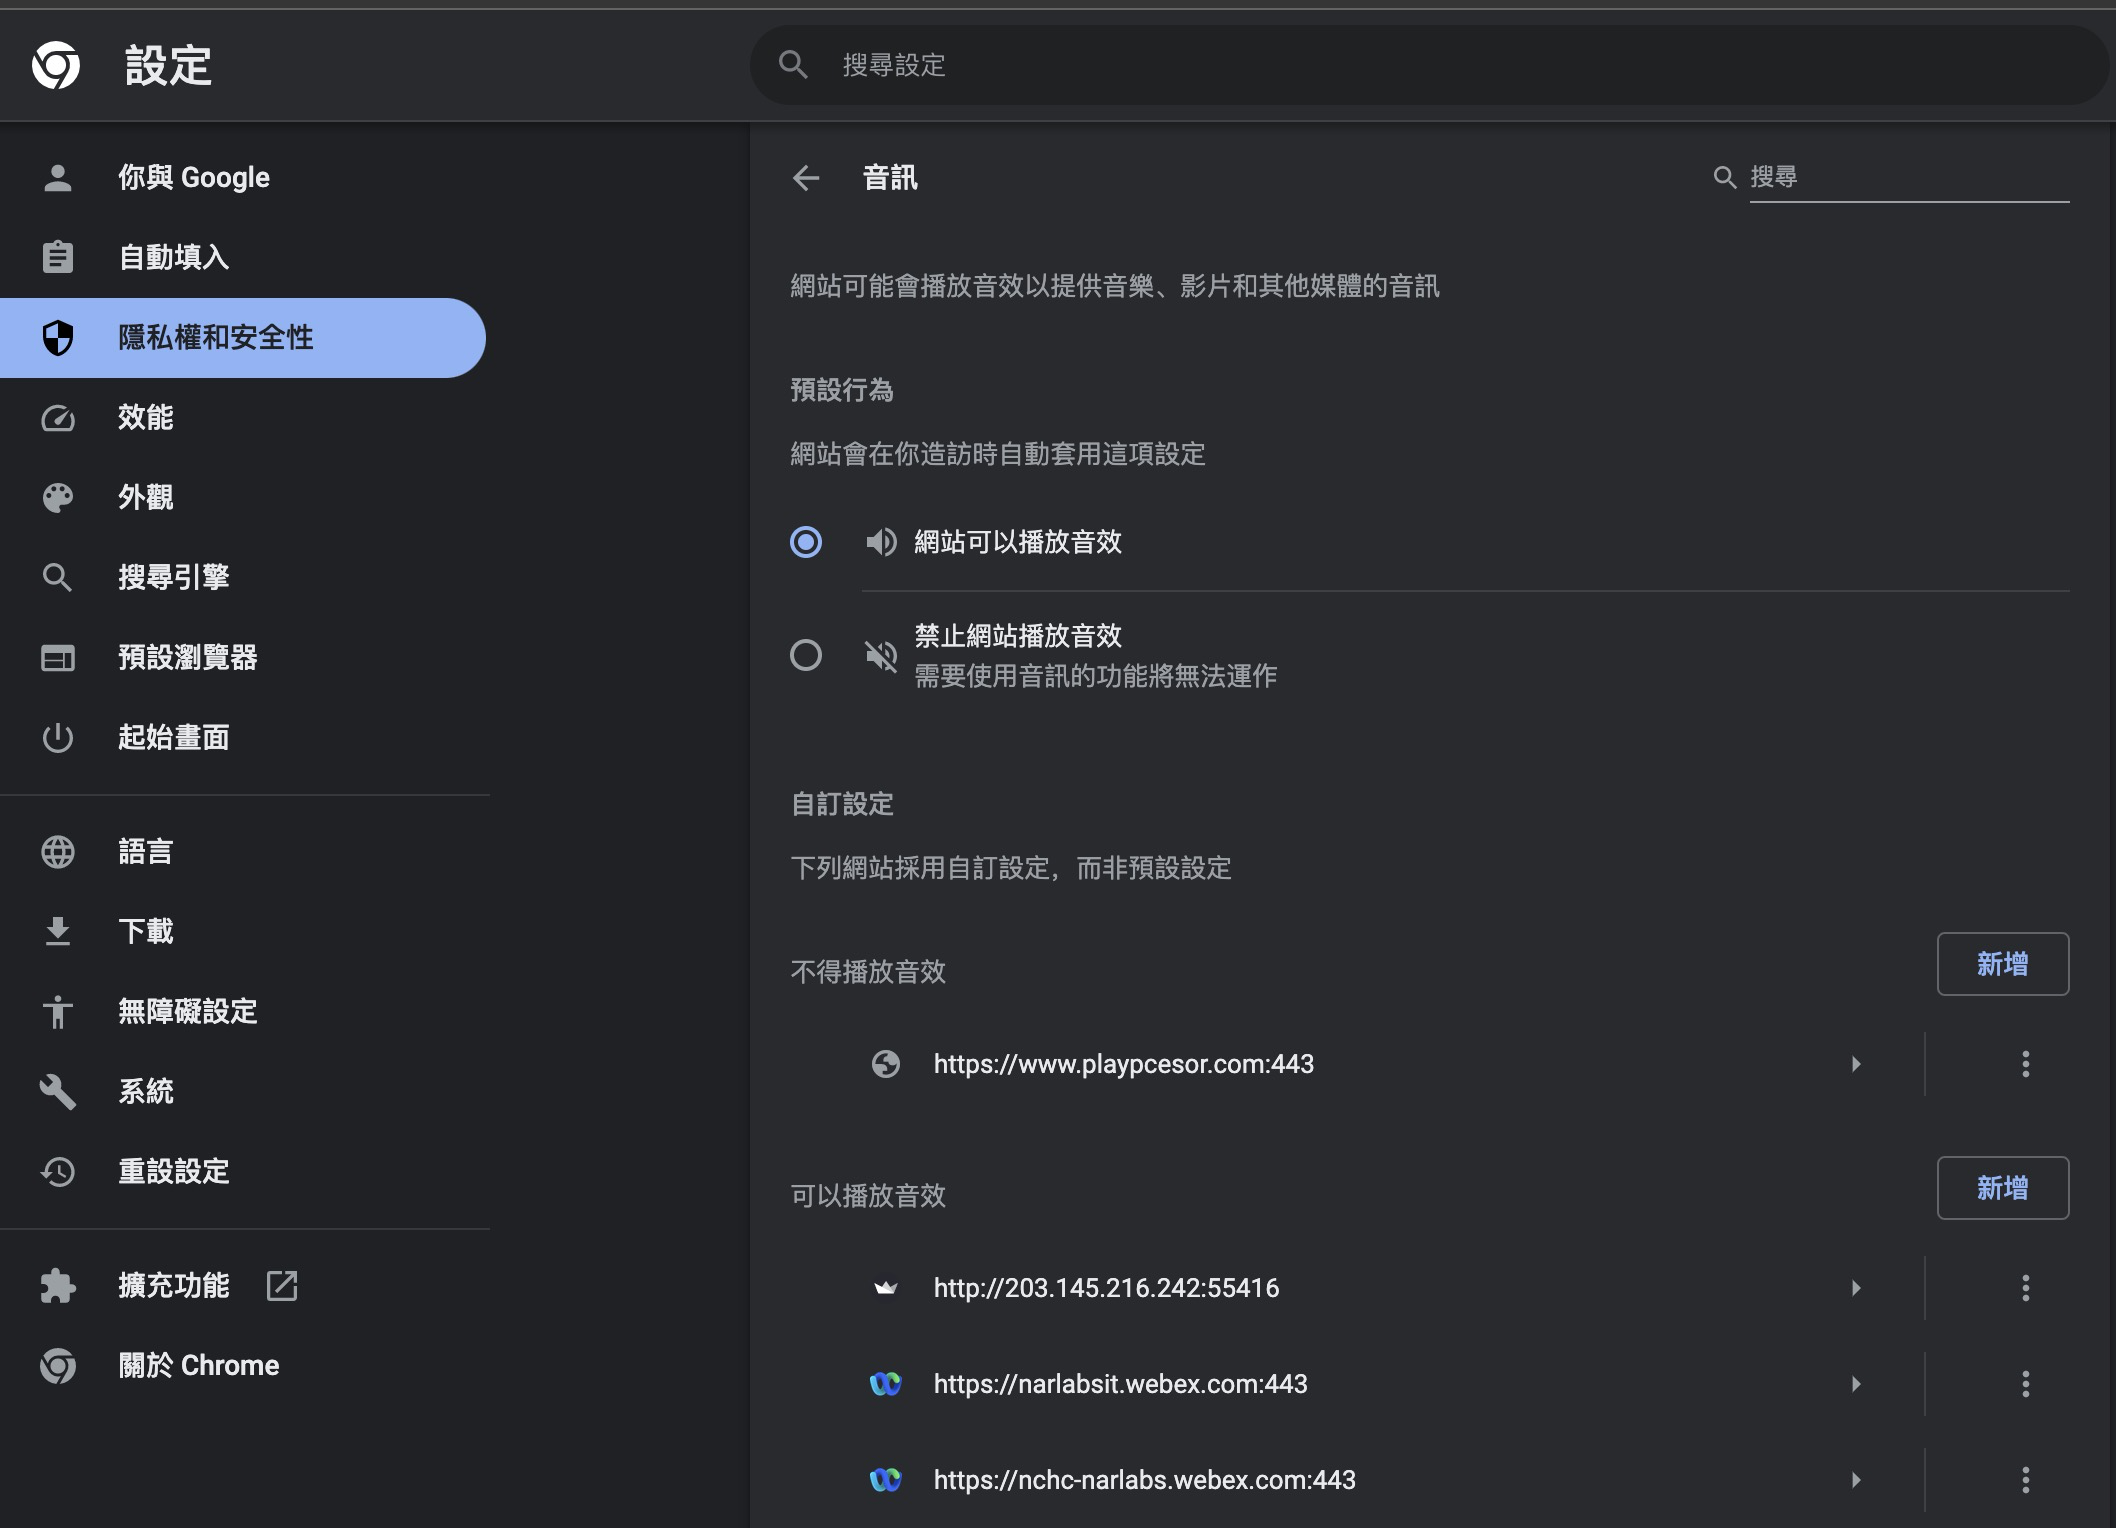

In [3]:
import base64

import streamlit as st


def autoplay_audio(file_path: str):
    with open(file_path, "rb") as f:
        data = f.read()
        b64 = base64.b64encode(data).decode()
        md = f"""
            <audio controls autoplay="true">
            <source src="data:audio/mp3;base64,{b64}" type="audio/mp3">
            </audio>
            """
        st.markdown(
            md,
            unsafe_allow_html=True,
        )


st.write("# Auto-playing Audio!")

autoplay_audio("speech.mp3")

# gTTS 
# + Streamlit Test

### Add Text-to-Speech to Your Web App with 5 Lines of Python Code
    [2023-03-21]

    Port and app test

        example: https://medium.com/@pavlo_sydorenko/add-text-to-speech-to-your-web-app-with-5-lines-of-python-code-8c4707f2dc93

        sudo pip install streamlit
        sudo pip install gTTS   (有中文喔 就是google翻譯中所使用的語音工具 僅有女聲)


$streamlit run bg_remove.py --server.address 0.0.0.0 --server.port 5000
$streamlit run bg_remove_tell-gTTS.py --server.address 0.0.0.0 --server.port 5000



    [2023-03-24] 發現有中文，重新測試，因為pyttsx3背後用的eSpeak發音太糟糕了！
        完成測試gTTS比較好，跟人聲語調還是有點差距！

        gTTS 所有的語音都是用某種成年女性的聲音。有什麼辦法可以自定義gTTS讀取文本的聲音嗎？
            確認：僅有女性聲音且中文語音是沒有腔調可換！！！僅有英文可換地區腔調！
    

In [3]:
from gtts import gTTS
from io import BytesIO

sound_file = BytesIO()

# tts = gTTS('Add text-to-speech to your app', lang='en')
tts = gTTS('森山小姐，我相信你。Add text-to-speech to your app', lang='zh-TW')

tts.write_to_fp(sound_file)

tts.save("speech.mp3")

st.audio(sound_file)

# pyttsx3

    [2023-03-24] pyttsx3僅在Linux下發音很糟(因為espeak)，但windows Mac因使用系統的語音所以表現較好。

sudo apt update
sudo apt install espeak
sudo apt install ffmpeg


sudo pip install pyttsx3


espeak centos 中文问题 https://www.jianshu.com/p/1a5f5d450c12

    git clone https://github.com/harry0731/espeak.git
    cd espeak/dictsource/
    sudo espeak --compile=zh # to install to sys.


[pyttsx3在ubutnu用的espeak 中文發音非常糟 像是歪果仁講中文！！] 去找PPTTS試試看
在Ubuntu下，默認的這個語音包，是個歪果仁，說的中文確確實實是那種歪果仁說中文的感覺，而且整體音色機械音。
為啥Win和liunx播放效果如此區別呢？Windows上使用的是sapi5語音合成引擎，Mac OS X上是nsspeech合成器，eSpeak 其他平台上使用，即，linux上使用的espeak。

而且espeak關聯套件非常地多太耗空間

In [ ]:
# Import the required module
import pyttsx3

# Create a string
string = "Lorem Ipsum is simply dummy text " \
	+ "of the printing and typesetting industry."

# Initialize the Pyttsx3 engine
engine = pyttsx3.init()

# We can use file extension as mp3 and wav, both will work
engine.save_to_file(string, 'speech.mp3')

# Wait until above command is not finished.
engine.runAndWait()


# PPTTS
https://github.com/PaddlePaddle/PaddleSpeech/blob/develop/docs/source/tts/PPTTS.md


PP-TTS 是 PaddleSpeech 自研的流式语音合成系统。


## PaddleSpeech安裝方式有三裝
https://github.com/PaddlePaddle/PaddleSpeech/blob/develop/docs/source/install_cn.md

先用簡單安裝試試
注意都用sudo安裝在容器裡 不是個人目錄下喔

2023-03-24 簡單安裝法失敗 考慮用docker方式安裝


In [ ]:
依照簡單方法安裝，但使用時報錯。

$sudo pip install pytest-runner
$sudo pip install paddlepaddle -i https://mirror.baidu.com/pypi/simple
$sudo pip install paddlespeech

$paddlespeech tts --input "你好，欢迎使用百度飞桨深度学习框架！" --output output.wav
Traceback (most recent call last):
File "/usr/local/bin/paddlespeech", line 8, in
sys.exit(_execute())
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/cli/entry.py", line 40, in _execute
exec("from {} import {}".format(module, cls))
File "", line 1, in
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/cli/tts/init.py", line 14, in
from .infer import TTSExecutor
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/cli/tts/infer.py", line 33, in
from paddlespeech.t2s.exps.syn_utils import get_am_inference
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/t2s/init.py", line 18, in
from . import frontend
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/t2s/frontend/init.py", line 15, in
from .normalizer import *
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/t2s/frontend/normalizer/init.py", line 14, in
from paddlespeech.t2s.frontend.normalizer.normalizer import *
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/t2s/frontend/normalizer/normalizer.py", line 18, in
from paddlespeech.t2s.frontend.normalizer.numbers import normalize_numbers
File "/usr/local/lib/python3.8/dist-packages/paddlespeech/t2s/frontend/normalizer/numbers.py", line 17, in
import inflect
File "/usr/local/lib/python3.8/dist-packages/inflect/init.py", line 76, in
from pydantic import Field, validate_arguments
File "pydantic/init.py", line 2, in init pydantic.init
File "pydantic/dataclasses.py", line 41, in init pydantic.dataclasses
# +---------+-----------------------------------------+
ImportError: cannot import name dataclass_transform

In [1]:
from paddlespeech.cli.tts.infer import TTSExecutor
tts = TTSExecutor()
tts(text="今天天气十分不错。", output="output.wav")

ImportError: cannot import name dataclass_transform

# 雅婷文字轉語音

[2023-03-25] 嘗試

目前中文語音中最自然最像人的，(ppspeech沒試過)

台灣人工智慧實驗室的產品 
要有熟人才能找來試用 或是一邀請作為盲人團體的限量免費服務，或是折抵服務之類的。
https://tts.yating.tw/
https://www.yating.tw/zh/api-text-to-speech-zh/

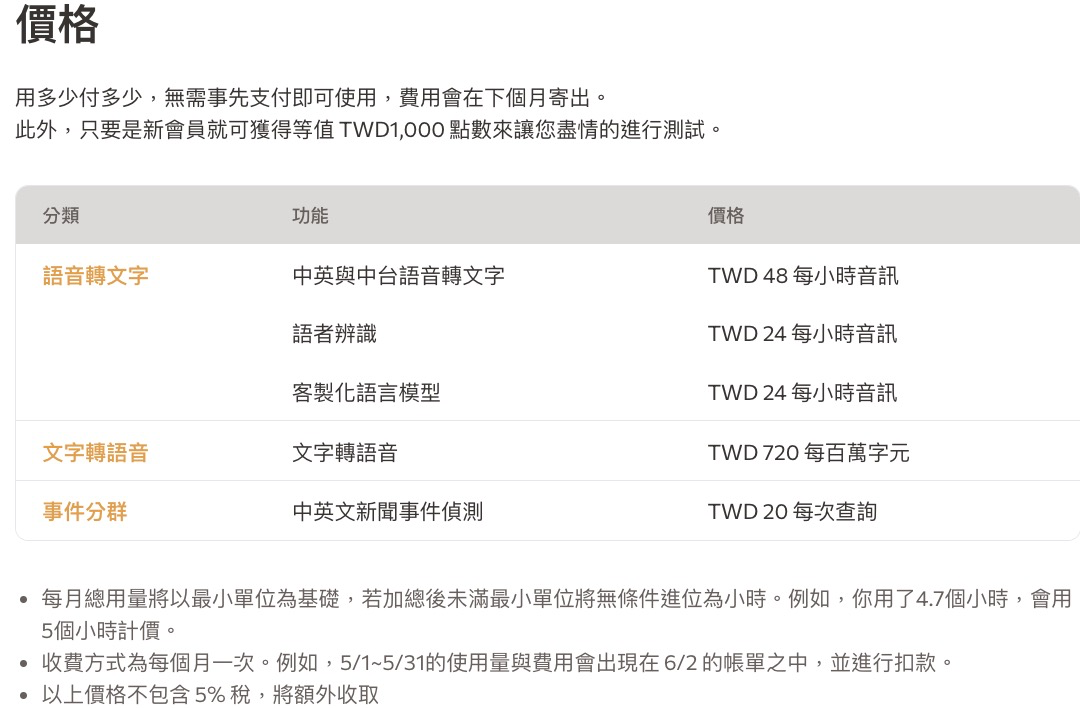


加入會員帳號，先使用1000元測試，


請注意，一個中文字用 2 個字符計算，全形符號兩個字符，半形符號與空格一個字符。

|TTS |安裝難度|中文發音品質|使用成本|
|-----|--------|--------|--------|
|gTTS|低       |高|Free|
|pyttsx3  |中      |低*|Free|
|PPTTS  |高      |高**|Free|
|雅婷TTS  |低      |極高***|720TWD/每百萬字元#|

`*僅指Linux下使用espeak時 **僅指PPTTS之試聽檔案 ***實際API試用 #請注意，一個中文字用 2 個字符計算，全形符號兩個字符，半形符號與空格一個字符。`

雅婷API範例
https://developer.yating.tw/doc/tts-%E8%AA%9E%E9%9F%B3%E5%90%88%E6%88%90#%E7%AF%84%E4%BE%8B

Yating TTS SDK - Python version （要跟對方取得api key喔）
https://github.com/TaiwanAILabs-Yating/tts-sdk-python 

sudo pip install Yating-TTS-SDK

語音合成

Service: https://tts.api.yating.tw/v1

讓您將文本藉由 REST API 轉換為合成語音，並且支援自然的的聲調與特定語言，接下來說明如何用 http request 來取得文字轉語音服務。

Step1：使用 /speeches/short

Step2：透過 base64 解碼 `audioContent` 並存成音檔

輸入的本文可以是純文字或是SSML(如果你想要語音內容多一點變化與彈性)。有關 SSML 支援的功能，請看這裡。

進行語音合成

在處理完所有輸入後，一般情況下，回應時間低於 60 秒。

Request

URL: https://tts.api.yating.tw/v1/speeches/short

Method: POST

In [4]:
"""
Example code for yating tts api call.
"""

from yating_tts_sdk import YatingClient as ttsClient

URL = "https://tts.api.yating.tw/v1/speeches/short"
KEY = "8ae54460da87873e1edc992b234adc90c79a6665"


TEXT = "歡迎收聽雅婷文字轉語音"
TEXT_TYPE = ttsClient.TYPE_TEXT
MODEL = ttsClient.MODEL_FEMALE_1
ENCODING = ttsClient.ENCODING_MP3
SAMPLE_RATE = ttsClient.SAMPLE_RATE_16K
FILE_NAME = "example"


client = ttsClient(URL, KEY)
client.synthesize(TEXT, TEXT_TYPE, MODEL,
                  ENCODING, SAMPLE_RATE, FILE_NAME) #會自動下載example.mp3到本地

# Good Tape (這是語音轉文字) 目前API還是免費
生成式AI席捲全球，來自丹麥小國的語音辨識軟體公司Good Tape，如何快速掌握OpenAI開源模型Whisper，短時間追上中國科大訊飛、台灣雅婷，成為記者、Podcaster愛用的工具？




ImportError: libGL.so.1: cannot open shared object file: No such file or directory¶
For libGL.so, sudo apt update -qq; sudo apt install -y libgl1-mesa-glx ; sudo apt install -y libsm6 libxrender1 ;